In [1]:
# Imports
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [13]:
# Load raw dataset
df_multi = pd.read_csv(
    '../../raw_data/big_startup_secsees_dataset.csv'
)

In [14]:
# Dataset shape
df_multi.shape

(66368, 14)

In [15]:
# Check columns
df_multi.columns.tolist()

['permalink',
 'name',
 'homepage_url',
 'category_list',
 'funding_total_usd',
 'status',
 'country_code',
 'state_code',
 'region',
 'city',
 'funding_rounds',
 'founded_at',
 'first_funding_at',
 'last_funding_at']

In [16]:
# Check target values
df_multi['status'].value_counts()

status
operating    53034
closed        6238
acquired      5549
ipo           1547
Name: count, dtype: int64

In [18]:
# Check missing values
df_multi.isnull().sum().sort_values(ascending=False).head(20)

founded_at           15221
state_code            8547
region                8030
city                  8028
country_code          6958
homepage_url          5058
category_list         3148
first_funding_at        24
name                     1
permalink                0
status                   0
funding_total_usd        0
funding_rounds           0
last_funding_at          0
dtype: int64

In [19]:
# Preview dataset
df_multi.head()


,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
0,/organization/-fame,#fame,http://livfame.com,Media,10000000,operating,IND,16,Mumbai,Mumbai,1,NaN,2015-01-05,2015-01-05
1,/organization/-qounter,:Qounter,http://www.qounter.com,Application Platforms|Real Time|Social Network...,700000,operating,USA,DE,DE - Other,Delaware City,2,2014-09-04,2014-03-01,2014-10-14
2,/organization/-the-one-of-them-inc-,"(THE) ONE of THEM,Inc.",http://oneofthem.jp,Apps|Games|Mobile,3406878,operating,NaN,NaN,NaN,NaN,1,NaN,2014-01-30,2014-01-30
3,/organization/0-6-com,0-6.com,http://www.0-6.com,Curated Web,2000000,operating,CHN,22,Beijing,Beijing,1,2007-01-01,2008-03-19,2008-03-19
4,/organization/004-technologies,004 Technologies,http://004gmbh.de/en/004-interact,Software,-,operating,USA,IL,"Springfield, Illinois",Champaign,1,2010-01-01,2014-07-24,2014-07-24


In [20]:
# Class percentages
round(df_multi['status'].value_counts(normalize=True) * 100, 2)

status
operating    79.91
closed        9.40
acquired      8.36
ipo           2.33
Name: proportion, dtype: float64

In [21]:
# Keep selected columns
df_multi = df_multi[
    [
        'category_list',
        'funding_total_usd',
        'country_code',
        'state_code',
        'funding_rounds',
        'status',
        'founded_at',
        'first_funding_at',
        'last_funding_at'
    ]
]

In [22]:
# Dataset shape
df_multi.shape

(66368, 9)

In [23]:
# Extract founded year
df_multi['founded_year'] = pd.to_datetime(
    df_multi['founded_at'],
    errors='coerce'
).dt.year

In [24]:
# Extract first funding year
df_multi['first_funding_at'] = pd.to_datetime(
    df_multi['first_funding_at'],
    errors='coerce'
)

df_multi['first_funding_year'] = (
    df_multi['first_funding_at']
    .dt.year
)

In [25]:
# Extract last funding year
df_multi['last_funding_at'] = pd.to_datetime(
    df_multi['last_funding_at'],
    errors='coerce'
)

df_multi['last_funding_year'] = (
    df_multi['last_funding_at']
    .dt.year
)

In [26]:
# Drop date columns
df_multi = df_multi.drop(
    columns=[
        'founded_at',
        'first_funding_at',
        'last_funding_at'
    ]
)

In [27]:
# Check columns
df_multi.columns.tolist()

['category_list',
 'funding_total_usd',
 'country_code',
 'state_code',
 'funding_rounds',
 'status',
 'founded_year',
 'first_funding_year',
 'last_funding_year']

In [28]:
df_multi.shape

(66368, 9)

# Feature Engineering for Multi Class Classification

In [30]:
# Time to first funding
# Measures how quickly a startup attracted investors
df_multi['years_to_first_funding'] = (
    df_multi['first_funding_year']
    - df_multi['founded_year']
)

In [31]:
# Funding duration
# Measures how long funding activity continued
df_multi['funding_duration'] = (
    df_multi['last_funding_year']
    - df_multi['first_funding_year']
)

In [33]:
# Check data type
df_multi['funding_total_usd'].dtype

dtype('O')

In [34]:
# Sample values
df_multi['funding_total_usd'].head()

0    10000000
1      700000
2     3406878
3     2000000
4           -
Name: funding_total_usd, dtype: object

In [35]:
# Convert funding amount to numeric
df_multi['funding_total_usd'] = pd.to_numeric(
    df_multi['funding_total_usd'],
    errors='coerce'
)

In [36]:
# Check data type
df_multi['funding_total_usd'].dtype

dtype('float64')

In [37]:
# Log funding amount
# Reduces the impact of extreme funding values
df_multi['log_funding_total_usd'] = np.log1p(
    df_multi['funding_total_usd']
)

In [38]:
# Check data types
df_multi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66368 entries, 0 to 66367
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   category_list           63220 non-null  object 
 1   funding_total_usd       53583 non-null  float64
 2   country_code            59410 non-null  object 
 3   state_code              57821 non-null  object 
 4   funding_rounds          66368 non-null  int64  
 5   status                  66368 non-null  object 
 6   founded_year            51143 non-null  float64
 7   first_funding_year      66341 non-null  float64
 8   last_funding_year       66368 non-null  int32  
 9   years_to_first_funding  51120 non-null  float64
 10  funding_duration        66341 non-null  float64
 11  log_funding_total_usd   53583 non-null  float64
dtypes: float64(6), int32(1), int64(1), object(4)
memory usage: 5.8+ MB


In [39]:
# Missing values
df_multi[
    [
        'funding_total_usd',
        'founded_year',
        'first_funding_year',
        'last_funding_year'
    ]
].isnull().sum()

funding_total_usd     12785
founded_year          15225
first_funding_year       27
last_funding_year         0
dtype: int64

In [40]:
# Average funding per round
# Captures funding intensity
df_multi['funding_per_round'] = (
    df_multi['funding_total_usd']
    / df_multi['funding_rounds']
)

In [41]:
# Multiple funding rounds
# Indicates repeated investor support
df_multi['multiple_rounds'] = (
    df_multi['funding_rounds'] > 1
).astype(int)

In [42]:
# Early funding indicator
# Startup received funding within 2 years
df_multi['early_funding'] = (
    df_multi['years_to_first_funding'] <= 2
).astype(int)

In [43]:
# High funding indicator
# Funding above median level
median_funding = df_multi['funding_total_usd'].median()

df_multi['high_funding'] = (
    df_multi['funding_total_usd'] > median_funding
).astype(int)

In [44]:
# Dataset shape
df_multi.shape

(66368, 16)

In [45]:
# Class distribution
df_multi['status'].value_counts(normalize=True) * 100

status
operating    79.908992
closed        9.399108
acquired      8.360957
ipo           2.330943
Name: proportion, dtype: float64

In [46]:
# Features
X = df_multi.drop(columns='status')

# Target
y = df_multi['status']

In [47]:
# Split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [48]:
# Numerical features
num_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

num_features

['funding_total_usd',
 'funding_rounds',
 'founded_year',
 'first_funding_year',
 'years_to_first_funding',
 'funding_duration',
 'log_funding_total_usd',
 'funding_per_round',
 'multiple_rounds',
 'early_funding',
 'high_funding']

In [49]:
# Categorical features
cat_features = X.select_dtypes(
    include=['object']
).columns.tolist()

cat_features

['category_list', 'country_code', 'state_code']

In [50]:
# Check columns
X.columns.tolist()

['category_list',
 'funding_total_usd',
 'country_code',
 'state_code',
 'funding_rounds',
 'founded_year',
 'first_funding_year',
 'last_funding_year',
 'years_to_first_funding',
 'funding_duration',
 'log_funding_total_usd',
 'funding_per_round',
 'multiple_rounds',
 'early_funding',
 'high_funding']

In [51]:
# Numerical features
num_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

num_features

['funding_total_usd',
 'funding_rounds',
 'founded_year',
 'first_funding_year',
 'years_to_first_funding',
 'funding_duration',
 'log_funding_total_usd',
 'funding_per_round',
 'multiple_rounds',
 'early_funding',
 'high_funding']

In [52]:
# Train shape
X_train.shape

(53094, 15)

In [53]:
# Test shape
X_test.shape

(13274, 15)

In [54]:
# Preprocessing imports
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [55]:
# Numerical preprocessing
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [56]:
# Categorical preprocessing
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [57]:
# Combine preprocessing steps
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

In [58]:
# Multiclass logistic regression
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ))
])

In [59]:
# Train model
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [60]:
# Predictions
y_pred = model.predict(X_test)

In [61]:
# Classification report
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

    acquired       0.28      0.48      0.36      1110
      closed       0.20      0.39      0.27      1248
         ipo       0.12      0.52      0.20       309
   operating       0.90      0.65      0.76     10607

    accuracy                           0.61     13274
   macro avg       0.38      0.51      0.39     13274
weighted avg       0.76      0.61      0.66     13274



In [62]:
# Confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[ 535,  186,  132,  257],
       [ 239,  481,   73,  455],
       [  68,   22,  160,   59],
       [1040, 1678,  967, 6922]])

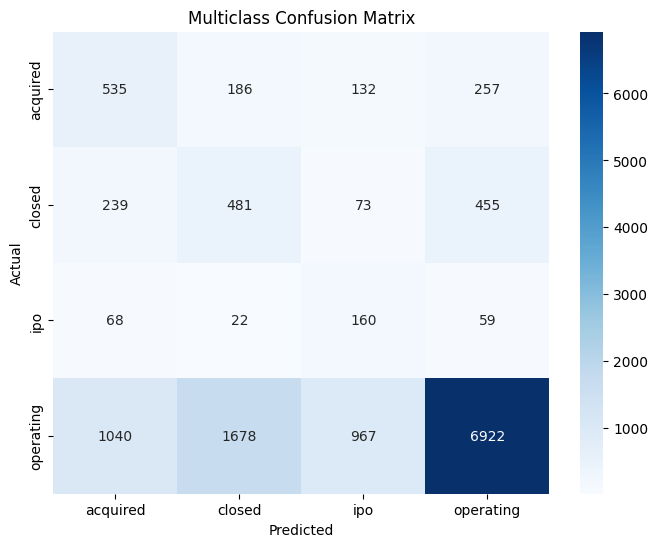

In [63]:
# Confusion matrix heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Multiclass Confusion Matrix')

plt.show()

# Multiclass Model Results

The multiclass logistic regression model achieved an overall accuracy of 61%.

The model performed best on the operating class, achieving an F1-score of 0.76. Performance was lower for acquired, closed, and ipo classes due to class imbalance and overlapping startup characteristics.

The macro-average F1-score of 0.39 indicates that the model learned useful patterns across all four startup outcomes but still faces challenges distinguishing between less common classes.

The confusion matrix shows that most classification errors occur between operating, acquired, and closed startups.

In [64]:
# Random Forest import
from sklearn.ensemble import RandomForestClassifier

In [65]:
# Random Forest pipeline
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

In [66]:
# Train model
rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [67]:
# Make predictions
rf_pred = rf_model.predict(X_test)

In [68]:
# Evaluate model
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

    acquired       0.40      0.09      0.15      1110
      closed       0.36      0.13      0.19      1248
         ipo       0.41      0.04      0.07       309
   operating       0.82      0.96      0.88     10607

    accuracy                           0.79     13274
   macro avg       0.50      0.31      0.32     13274
weighted avg       0.73      0.79      0.74     13274



In [69]:
# The model learned "If unsure, predict operating"!

In [71]:
pip install xgboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 20.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.4/303.4 MB 12.0 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip available: 22.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [72]:
import xgboost

print(xgboost.__version__)

3.2.0


In [73]:
# Encode target labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = le.fit_transform(y)

print(le.classes_)

['acquired' 'closed' 'ipo' 'operating']


In [74]:
# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [75]:
# XGBoost
from xgboost import XGBClassifier

In [76]:
# XGBoost pipeline
xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        objective='multi:softmax',
        num_class=4,
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='mlogloss'
    ))
])

In [77]:
# Train XGBoost
xgb_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [78]:
# Predictions
xgb_pred = xgb_model.predict(X_test)

In [79]:
# Evaluation
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

    acquired       0.46      0.21      0.29      1110
      closed       0.49      0.09      0.15      1248
         ipo       0.47      0.10      0.17       309
   operating       0.83      0.97      0.89     10607

    accuracy                           0.81     13274
   macro avg       0.56      0.34      0.37     13274
weighted avg       0.76      0.81      0.76     13274



In [80]:
# The class imbalance is dominating the model.
# XGBoost became extremely confident in predicting "Operating" but not so good with smaller classes.

In [81]:
pip install imbalanced-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.1/236.1 kB 2.3 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip available: 22.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [82]:
import imblearn

print(imblearn.__version__)

0.14.2


In [83]:
# Transform training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data
X_test_processed = preprocessor.transform(X_test)

In [84]:
# SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

In [85]:
# Original class counts
pd.Series(y_train).value_counts()

3    42427
1     4990
0     4439
2     1238
Name: count, dtype: int64

In [86]:
# SMOTE class counts
pd.Series(y_train_smote).value_counts()

3    42427
0    42427
1    42427
2    42427
Name: count, dtype: int64

In [87]:
# XGBoost model
from xgboost import XGBClassifier

xgb_smote = XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

In [88]:
# Train model
xgb_smote.fit(
    X_train_smote,
    y_train_smote
)

,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [89]:
# Predictions
xgb_smote_pred = xgb_smote.predict(
    X_test_processed
)

In [90]:
# Classification report
print(
    classification_report(
        y_test,
        xgb_smote_pred,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

    acquired       0.37      0.42      0.39      1110
      closed       0.32      0.33      0.32      1248
         ipo       0.28      0.33      0.30       309
   operating       0.88      0.85      0.86     10607

    accuracy                           0.75     13274
   macro avg       0.46      0.48      0.47     13274
weighted avg       0.77      0.75      0.76     13274



# XGBoost with SMOTE Results

Class imbalance significantly affected model performance in the multiclass classification task.

To address this issue, SMOTE (Synthetic Minority Oversampling Technique) was applied to the training data before fitting an XGBoost classifier.

The resulting model achieved:

- Accuracy: 75%
- Macro F1 Score: 0.47

Compared with previous models, XGBoost combined with SMOTE produced the strongest balanced performance across all startup outcome classes. While overall accuracy decreased slightly compared with standard XGBoost, recall and F1-scores improved substantially for the minority classes (acquired, closed, and ipo).

This demonstrates the importance of addressing class imbalance when predicting startup outcomes.

In [92]:
# Compare model performance
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost',
        'XGBoost + SMOTE'
    ],
    'Macro_F1': [
        0.39,
        0.32,
        0.37,
        0.47
    ]
})

comparison

,Model,Macro_F1
0,Logistic Regression,0.39
1,Random Forest,0.32
2,XGBoost,0.37
3,XGBoost + SMOTE,0.47


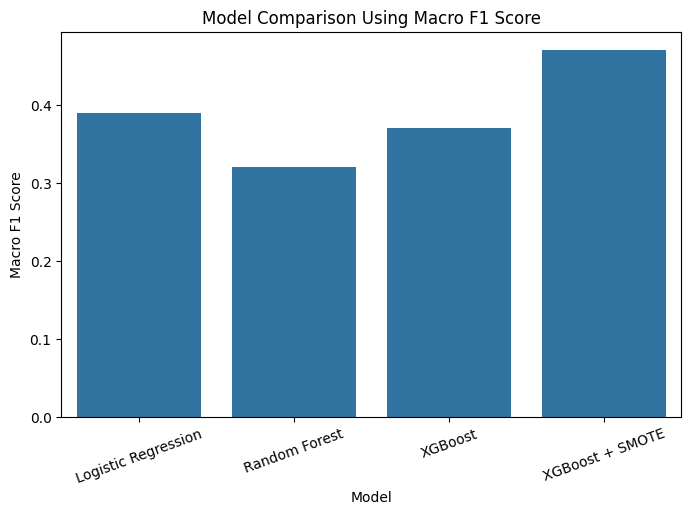

In [93]:
# Performance comparison chart
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x='Model',
    y='Macro_F1'
)

plt.title('Model Comparison Using Macro F1 Score')
plt.ylabel('Macro F1 Score')
plt.xlabel('Model')

plt.xticks(rotation=20)

plt.show()

# The highest accuracy model was not the best model. XGBoost + SMOTE produced the strongest balanced performance across all startup outcome classes.